<h1 style="color: #C0392B;">
Les régions françaises métropolitaines les plus dynamiques : peut-on expliquer la création d’entreprise ?</h1>



<span style="color: #2E86C1;"> *Par Tom Proust, Tristan Czarnecki et Thomas Favant*
</span>.

Pourquoi certaines régions françaises voient-elles naître beaucoup plus d’entreprises que d’autres ? À l’heure où la création d’entreprises est souvent présentée comme un levier majeur de dynamisme économique et territorial, nous avons cherché à mesurer, comparer et expliquer ces écarts à l’échelle régionale.

Pour cela, nous exploitons plusieurs jeux de données open data publics afin d’analyser la création d’entreprises au sens large, sans distinction de taille ou de statut juridique. Cette approche permet de capter l’ensemble du phénomène entrepreneurial et d’en suivre l’évolution dans le temps.

Pour simplifier la récupération des données et avoir une précision maximale, nous avons réduit l'étude à la France métropolitaine.

Ce travail s’inscrit dans le cadre du cours Python pour la Data Science (ENSAE Paris) et respecte pleinement ses attendus. Il s’articule autour de trois axes complémentaires :

- récupération et traitement de données multi-sources ;

- analyse statistique descriptive et visualisation ;

- modélisation explicative et prédictive.

L’ensemble du projet est conçu dans un souci de reproductibilité, de clarté méthodologique et de synthèse des résultats.

### Installation des bibliothèques

In [1]:
#mettre tous les imports nécessaires pour l'exécution de toutes les fonctions du dossiers 'mes_fonctions.py'
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import geopandas as gpd
from cartiflette import carti_download
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
import numpy as np

### Plan

1.	Récupération de données
2.	Statistiques descriptives
3.	Modélisation

<h1 style="color: #C0392B;">
1. Récupération des données </h1>

In [2]:
# Centraliser les paths

from pathlib import Path
import sys

# Racine du projet (le repo cloné)
PROJECT_ROOT = Path(".").resolve()

# Rendre src/ importable
sys.path.append(str(PROJECT_ROOT / "src"))


In [3]:
#Récupération de quelques bibliothèques (la majorité étant dans mes_fonctions)
from cartiflette import carti_download

## Construction de la variable cible 𝑌


La construction de la variable cible  a fait l’objet d’une réflexion méthodologique en amont. Bien que les données de créations d’entreprises soient publiées par l’INSEE, leur structure agrège plusieurs niveaux géographiques et plusieurs types de mesures, ce qui rend leur utilisation directe trompeuse.
Une exploration initiale du fichier brut a mis en évidence des risques de double comptage et des incohérences lors des agrégations. Nous avons donc procédé à un filtrage strict et à une reconstruction contrôlée des agrégats régionaux. 

L'INSEE est une source fiable, toutefois les ordres de grandeur obtenus ont ensuite été vérifiés par confrontation avec des séries publiées par l’INSEE et des sources institutionnelles externes (data.gouv, publications régionales), afin de valider la cohérence des résultats finaux.

In [4]:
from mes_fonctions import load_insee_head

load_insee_head(
    PROJECT_ROOT / "Data" / "data_outdated" / "Fichier INSEE.csv"
)



,FREQ,GEO,GEO_OBJECT,LEGAL_FORM,SIDE_MEASURE,TIME_PERIOD,OBS_VALUE
0,A,64,DEP,_T,BURE,2014,6042
1,A,47,DEP,_T,BURE,2024,4151
2,A,36,DEP,_T,BURE,2023,1928
3,A,44,REG,_T,BURE,2015,33719
4,A,55,DEP,_T,BURE,2015,884


### Étape 1 — Import et filtrage des données brutes

Le fichier INSEE est importé avec pandas. Il contient plusieurs niveaux géographiques et plusieurs types de mesures décrivant une même réalité économique. Afin d’éviter tout double comptage et de garantir une construction cohérente de la variable cible, les filtres suivants sont appliqués :

**Type de mesure**

On conserve uniquement les créations d’entreprises (unités légales) (SIDE_MEASURE == "BURE").
Le fichier INSEE regroupant également des cessations, des stocks ou des soldes, ce filtrage permet de définir une variable 
𝑌 économiquement homogène et interprétable.



**Niveau géographique**

On restreint l’analyse au niveau départemental (GEO_OBJECT == "DEP").
Le fichier contenant simultanément des données nationales, régionales et départementales, ce choix évite tout double comptage. Le niveau départemental constitue le niveau source le plus fin et permet de reconstruire de manière maîtrisée les agrégats régionaux par sommation.



**Période d’étude**

L’analyse est limitée aux années 2015 à 2024 afin de disposer d’une période récente et homogène, compatible avec les autres variables explicatives mobilisées dans le projet.



**Formes juridiques (si disponible)**

Lorsque l’information est présente, seules les observations correspondant au total toutes formes juridiques sont conservées. Cela permet d’éviter des redondances liées à la désagrégation par statut juridique.



**Typage des données**

La variable de valeur (OBS_VALUE) est convertie en numérique afin de permettre les agrégations et traitements statistiques ultérieurs.



À l’issue de ces filtrages, chaque observation correspond à une création d’entreprise unique, localisée à un département et une année donnés, fournissant une base propre et reproductible pour la construction de la variable régionale 𝑌.


### Étape 2 — Passage du niveau départemental au niveau régional

Les données INSEE étant fournies au niveau départemental, un changement d’échelle géographique est nécessaire.

- Un dictionnaire de correspondance département → région (codes INSEE) est défini explicitement.

- Chaque département est ainsi rattaché à sa région correspondante.

- Une vérification est effectuée afin de s’assurer qu’aucun département n’est perdu lors du mapping.

Les données sont ensuite agrégées par région et par année, en sommant le nombre de créations d’entreprises :

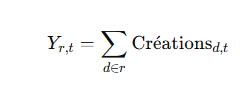

où 𝑑 désigne les départements appartenant à la région 𝑟.

Le résultat est un tableau structuré :

- code_region

- TIME_PERIOD (année)

- nb_creations


In [5]:
from mes_fonctions import build_y_insee_region_year

Y = build_y_insee_region_year(
    PROJECT_ROOT / "Data" / "data_outdated" / "Fichier INSEE.csv"
)

Y.head()

,code_region,TIME_PERIOD,nb_creations
0,11,2015,145628
1,11,2016,165621
2,11,2017,184150
3,11,2018,215995
4,11,2019,246394


### Étape 3 — Nettoyage et enrichissement du fichier final

Afin de rendre les données plus lisibles et directement exploitables pour l’analyse et la visualisation :

- Les noms officiels des régions sont ajoutés.

- Un code court (IDF, AURA, PACA, etc.) est créé pour faciliter les graphiques.

- Les observations sont triées par région et par année.

Le fichier final est exporté au format CSV avec encodage UTF-8.

In [6]:
from mes_fonctions import clean_y_insee_region_year

Y_clean = clean_y_insee_region_year(Y)
Y_clean.head()

,code_region,TIME_PERIOD,nb_creations,nom_region,code_court
0,11,2015,145628,Île-de-France,IDF
1,11,2016,165621,Île-de-France,IDF
2,11,2017,184150,Île-de-France,IDF
3,11,2018,215995,Île-de-France,IDF
4,11,2019,246394,Île-de-France,IDF


### Étape 4 : pondérer par la population

La variable cible initiale correspond au nombre de créations d’entreprises par région. Or, ce volume dépend mécaniquement de la taille de la population : une région plus peuplée crée davantage d’entreprises, même à dynamisme entrepreneurial identique. Comparer les régions à partir du nombre brut de créations introduirait donc un biais de taille.

Pour supprimer cet effet, on normalise le nombre de créations par la population régionale. On construit ainsi un taux de création d’entreprises pour 1 000 habitants, qui mesure l’intensité de la création entrepreneuriale indépendamment de la taille de la région. Cette transformation permet de rendre les régions comparables entre elles et fournit une variable cible plus pertinente pour l’analyse descriptive et la modélisation.

In [7]:
from mes_fonctions import construire_Y_taux_creation, afficher_top_bottom

# Chemins (adapte si besoin, mais garde l'idée : chemins relatifs au repo)
path_creation = "data/Variables explicatives/Variable_Y.csv"
path_pop = "data/Variables explicatives/population_par_region_annee.csv"

out_panel = None
out_avg = None

merged_df, avg_df = construire_Y_taux_creation(
    path_creation_csv=path_creation,
    path_population_csv=path_pop,
    out_path_panel=out_panel,
    out_path_avg=out_avg,
    facteur=1000,
    arrondi=2,
)

# Lisibilité : renommer pour l'affichage (optionnel, surtout pour ton rapport)
avg_affichage = avg_df.rename(columns={
    "region_nom": "Region",
    "creations_per_1000": "Création moyenne d'entreprise par an (2015–2025) pour 1 000 habitants"
})

display(merged_df.head())
display(avg_affichage.head())

# Top / bottom 3 (sur le df non renommé)
afficher_top_bottom(avg_df, col_region="region_nom", col_val="creations_per_1000", k=3)


,code_region,TIME_PERIOD,nb_creations,region_nom,code_court,population,creations_per_1000
0,11,2015,145628,Île-de-France,IDF,1.208214e+07,12.05
1,11,2016,165621,Île-de-France,IDF,1.211713e+07,13.67
2,11,2017,184150,Île-de-France,IDF,1.217488e+07,15.13
3,11,2018,215995,Île-de-France,IDF,1.221345e+07,17.69
4,11,2019,246394,Île-de-France,IDF,1.226254e+07,20.09


,Region,Création moyenne d'entreprise par an (2015–2025) pour 1 000 habitants
0,Auvergne-Rhône-Alpes,12.67
1,Bourgogne-Franche-Comté,9.17
2,Bretagne,9.25
3,Centre-Val de Loire,9.24
4,Corse,14.97


--- Les 3 plus faibles ---
                region_nom  creations_per_1000
7                Normandie                8.76
6          Hauts-de-France                8.89
1  Bourgogne-Franche-Comté                9.17

--- Les 3 plus élevés ---
                    region_nom  creations_per_1000
4                        Corse               14.97
11  Provence-Alpes-Côte d'Azur               16.67
12               Île-de-France               19.46


## Exemple de construction d'une variable explicative : population par région

### Étape 1 — Chargement des données brutes de population (INSEE)

La première étape consiste à charger le fichier INSEE contenant les estimations de population. Ce fichier est utilisé sans transformation immédiate, afin de conserver l’intégralité de l’information disponible (différents niveaux géographiques, tranches d’âge, sexes, années). Cette approche permet de vérifier la structure du jeu de données, d’identifier les colonnes pertinentes et d’éviter toute perte d’information prématurée. Le chargement séparé des données brutes facilite également le débogage et garantit la reproductibilité du pipeline.

In [8]:
#Fichier INSEE importé 

from mes_fonctions import load_population_region_year

pop_raw = load_population_region_year(
    PROJECT_ROOT / "Data" / "data_outdated" / "DS_ESTIMATION_POPULATION_data.csv"
)

pop_raw.head()


,GEO,GEO_OBJECT,SEX,AGE,EP_MEASURE,OBS_STATUS_FR,TIME_PERIOD,OBS_VALUE
0,78,DEP,M,Y50T54,POP,D,2007,44919
1,85,DEP,M,Y60T64,POP,D,2007,15680
2,82,DEP,F,Y15T19,POP,D,2007,6516
3,79,DEP,_T,Y25T29,POP,D,2007,19285
4,62,DEP,F,Y_LT5,POP,D,2007,47222


### Étape 2 — Construction du mapping géographique (code région → nom de région)

Les données INSEE reposent sur des codes géographiques (ex. REG-01) qui ne sont pas directement exploitables pour l’analyse ou la visualisation. Une étape intermédiaire consiste donc à construire un dictionnaire de correspondance entre ces codes et les noms des régions françaises. Cette opération s’appuie sur un fichier de référence officiel INSEE. Le mapping ainsi obtenu permet d’enrichir les données de population avec des libellés explicites, tout en assurant une cohérence géographique entre les différentes sources mobilisées dans le projet.

In [9]:
from mes_fonctions import build_region_name_mapping

mapping_region = build_region_name_mapping(
        PROJECT_ROOT / "Data" / "data_outdated" / "Liste de codes du dataset GEO (4).csv"
)

# aperçu (10-15 premières entrées)
list(mapping_region.items())[10:15]


[('44', 'Grand Est'),
 ('52', 'Pays de la Loire'),
 ('53', 'Bretagne'),
 ('75', 'Nouvelle-Aquitaine'),
 ('76', 'Occitanie')]

### Étape 3 — Filtrage, agrégation et construction des variables démographiques

Dans cette étape finale, les données sont restreintes aux régions et à la période d’étude retenue. Seules les observations correspondant à la population totale (tous âges, tous sexes) sont conservées afin d’obtenir une mesure cohérente de la population régionale.

Les données sont ensuite agrégées pour produire une variable population par région et par année. À partir de cette variable, des indicateurs complémentaires sont construits, notamment la variation annuelle de population (en pourcentage) et la densité de population, obtenue à partir des superficies régionales. Cette étape aboutit à un jeu de données synthétique, directement exploitable comme variable explicative dans l’analyse économétrique.

In [10]:
from mes_fonctions import build_population_region_year

pop = build_population_region_year(pop_raw, mapping_region, year_min=2014, year_max=2025)
pop.head()


,TIME_PERIOD,region_nom,population,pop_prev,variation_population_pourcentage,surface_km2,densite_population
0,2014,Auvergne-Rhône-Alpes,7.820966e+06,NaN,NaN,71134,109.95
1,2015,Auvergne-Rhône-Alpes,7.877698e+06,7.820966e+06,0.73,71134,110.74
2,2016,Auvergne-Rhône-Alpes,7.916889e+06,7.877698e+06,0.50,71134,111.30
3,2017,Auvergne-Rhône-Alpes,7.948287e+06,7.916889e+06,0.40,71134,111.74
4,2018,Auvergne-Rhône-Alpes,7.994459e+06,7.948287e+06,0.58,71134,112.39


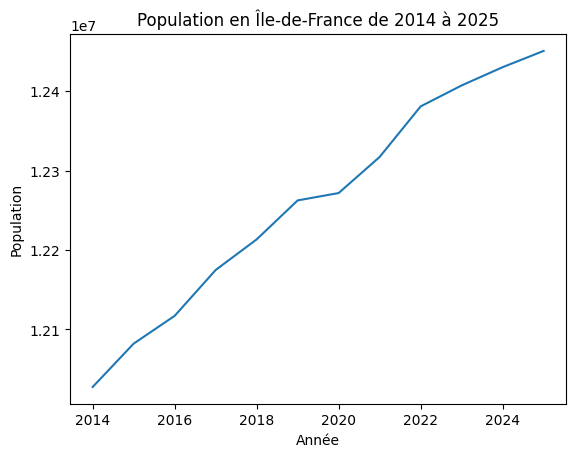

In [11]:
# Visualisation de l'évolution de la population en IDF

from mes_fonctions import plot_population_region

plot_population_region(pop, "Île-de-France")


## Autres variables explicatives

Nous avons trouvé pertinent d'inclure le chômage et les diplômes dans les variables explicatives (par région et par année).
Nous les avons récupérés sur le site de l'INSEE et avons menés des transformations similaires à l'aide de pandas.
Nous avons également mené une vérification via des sources croisées.

A noter :

-Toutes les variables explciatives sont des taux pour ne pas afficher l'influence de la population

-Le taux de diplômé par région étant presque similaire depuis 10 ans, nous avons seulement récupéré le taux de diplômé par région en 2022, et avons fait l'hypothèse que cette valeur était constante sur la période 2015-2024

L'intégralité des transformations menés se trouvent dans le sous-dossier extraction variables explicatives.

<h1 style="color: #C0392B;">
2. Statistiques descriptives </h1>

Avant de quantifier les relations par l'économétrie, l'analyse cartographique nous permet de mettre en évidence une géographie de l'inégalité entrepreneuriale. Nous chercherons notamment à voir si les zones de fort chômage coïncident spatialement avec les zones de faible création (test visuel de l'hypothèse 'Pull').

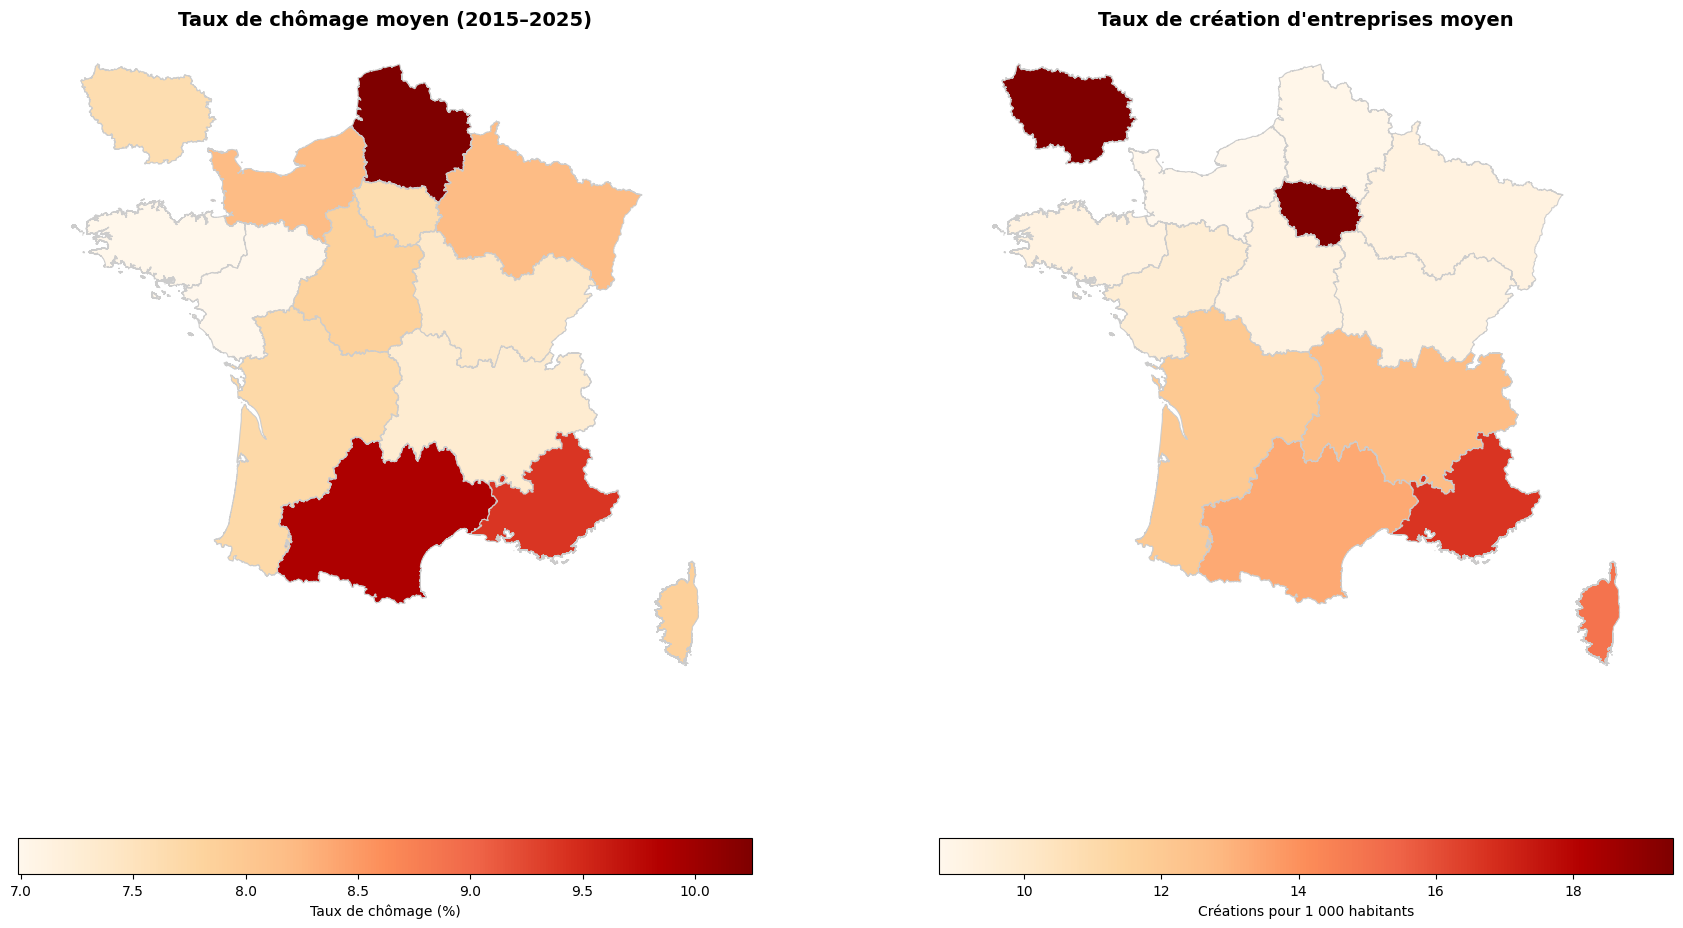

In [12]:
from mes_fonctions import carte_chomage_creation

regions = carti_download(
    values="France",
    crs=4326,
    borders="REGION",
    vectorfile_format="geojson",
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022,
)

carte_chomage_creation(
    regions_gdf=regions,
    path_chomage="data/Variables explicatives/chomage_format_long.csv",
    path_creation="data/Variables explicatives/avg_creation_2015_2025.csv",
)


### 1. Analyse de l'Hétérogénéité Spatiale : Une France à deux vitesses

L'observation de la carte du Taux de Création d'Entreprise Moyen (à droite) révèle de fortes disparités territoriales qui peuvent s'interpréter à travers plusieurs concepts de sociologie urbaine et de géographie économique.

**Le phénomène de Métropolisation et l'effet "Capitale"** : La carte met en évidence la position hégémonique de l'Île-de-France (en rouge foncé). Avec un taux de création supérieur à 16-18%, la région capitale illustre la concentration des capitaux, des talents (les "classes créatives" définies par Richard Florida) et des infrastructures. C'est l'illustration parfaite des économies d'agglomération : la densité d'acteurs économiques favorise l'innovation et la création de nouvelles structures.

**L'attrait du "Sunbelt" à la française (Héliotropisme)** : On observe une dynamique claire en faveur de la façade Atlantique et du Sud (Nouvelle-Aquitaine, Auvergne-Rhône-Alpes, PACA, Occitanie), représentées en orange soutenu. Cela correspond à un déplacement du centre de gravité économique vers les régions offrant un cadre de vie attractif, attirant une population souvent qualifiée ou désireuse de créer sa propre activité (néo-ruraux, entrepreneurs mobiles).

**La fracture territoriale (Centre-Périphérie)** : À l'opposé, les régions du Nord-Est (Grand-Est, Bourgogne-Franche-Comté) et du Centre-Val de Loire apparaissent en retrait (teintes claires). Cela reflète la persistance de la "Diagonale des faibles densités" ou des anciens bassins industriels en reconversion, où la culture entrepreneuriale peut être moins marquée et le tissu économique moins propice à l'émergence spontanée de startups ("écosystèmes moins matures").

### 2. Corrélation Visuelle : Chômage vs Création (Le test du "Négatif Photo")

La juxtaposition des deux cartes permet de tester visuellement l'hypothèse économique de l'effet "Pull" (l'économie saine attire la création).

Confirmation de la corrélation inverse dans le Nord : La région Hauts-de-France est le cas d'école qui valide notre modèle.

Carte de Gauche (Chômage) : Rouge foncé (Taux très élevé, > 9.5%).

Carte de Droite (Création) : Beige très clair (Taux très faible, < 12%).

**Conclusion** : Ici, la précarité économique agit clairement comme un frein. Le chômage élevé ne "pousse" pas à la création, il l'inhibe, confirmant l'absence d'entrepreneuriat de nécessité massif.

Le Paradoxe du Sud (La nuance nécessaire) : L'analyse visuelle permet de nuancer le modèle statistique global. Regardons l'Occitanie et la région PACA :

Elles ont des taux de chômage élevés (Rouge foncé à gauche).

Pourtant, elles ont aussi des taux de création élevés (Orange/Rouge à droite).

**Interprétation** : Cela suggère qu'un autre facteur compense l'effet négatif du chômage dans ces régions. Notre modèle de régression nous a donné la réponse : la Variation de la Population (coefficient +2.72). Le dynamisme démographique de ces régions (flux migratoires positifs) soutient la création d'entreprise malgré un chômage structurel élevé.

**Synthèse visuelle** : Globalement, on n'observe pas de superposition parfaite (les zones rouges de gauche ne sont pas les zones rouges de droite), ce qui confirme visuellement que le chômage n'est pas un moteur de création. Cependant, la relation n'est pas parfaitement linéaire partout : l'attractivité résidentielle (Sud) peut "casser" cette corrélation négative.

Il semble y avoir une corrélation négative entre chômage et création d'entreprise, qu'on va analyser.

Le but est d'analyser la corrélation entre le taux de chômage et la création d'entreprises par 1000 habitants dans différentes régions et périodes.Pour cela, on écrit une fonction dans 'analyse_correlation_chomage_creation.py' qui calcule le coefficient de corrélation de Pearson entre le taux de chômage et la création d'entreprises par 1000 habitants.

--- Analyse Statistique ---
Coefficient de corrélation (Pearson) : -0.35
Tendance : Inverse (Plus le chômage est haut, moins on crée).


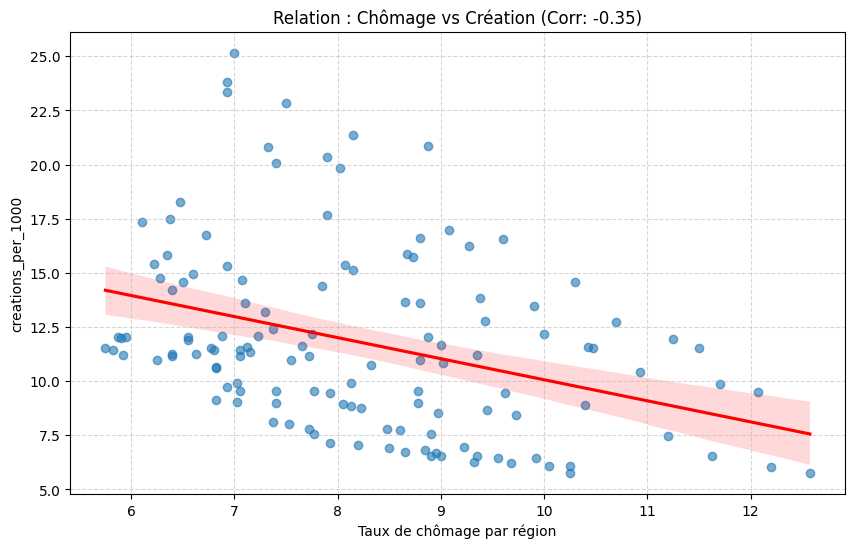

In [13]:
import pandas as pd
correlation_chomage_creation=pd.read_csv("data/Variables explicatives/correlation_chomage_creation.csv")

# Là, tu importes ta fonction depuis ton fichier
from mes_fonctions import analyser_relation_chomage_creation

# Et tu l'utilises
analyser_relation_chomage_creation(correlation_chomage_creation)



Analyse de la corrélation : confirmation statistique et nuances
Le nuage de points ci-contre permet d'objectiver et de quantifier la relation inverse pressentie lors de l'observation des cartes. L'analyse de cette distribution révèle trois enseignements majeurs :

1. Une corrélation négative confirmant la nature "pro-cyclique" Avec un coefficient de corrélation de -0.35, la relation est inverse et modérément significative. La pente descendante de la droite de régression indique clairement que la bonne santé économique (faible chômage) est davantage corrélée à la création d'entreprises que la précarité.

Hypothèse "Push" (Nécessité) écartée : Si le chômage était le moteur principal (création par "dépit" ou survie), la pente serait positive.

Hypothèse "Pull" (Opportunité) validée : Les données corroborent une dynamique d'opportunité. Un marché de l'emploi sain (signe de dynamisme économique, confiance des ménages, accès au crédit facilité) constitue un terreau plus fertile pour l'entrepreneuriat.

2. Le chômage comme facteur limitant ("Plafond de verre"). L'analyse visuelle de la distribution met en évidence une contrainte forte : au-delà de 10 % de chômage, le taux de création ne décolle jamais (aucun point supérieur à 15 créations pour 1000 habitants). Un contexte économique dégradé semble donc agir comme un frein structurel, "interdisant" les dynamiques entrepreneuriales fortes.

3. La condition nécessaire, mais non suffisante La partie gauche du graphique (chômage faible, entre 6 et 8 %) montre une très forte disparité. Si c'est dans cette zone que l'on trouve les records de création (> 20), on y trouve aussi des taux beaucoup plus modestes. Conclusion : Un faible chômage est une condition nécessaire pour permettre une forte création d'entreprises, mais elle n'est pas suffisante. D'autres déterminants locaux (attractivité touristique, métropolisation, politiques locales) interviennent pour transformer ce potentiel économique en création effective.

## Statistiques descriptives liées au taux de diplôme

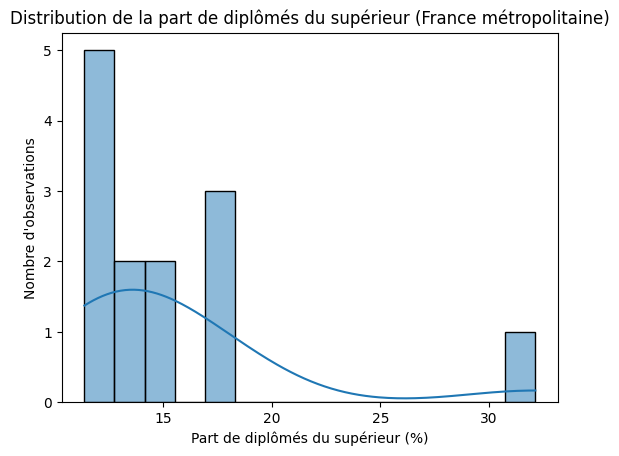

In [14]:
import pandas as pd

# Chargement du fichier diplôme
df_diplome = pd.read_csv("data/Variables explicatives/diplome_region.csv")

dom_tom = [
    "Guadeloupe",
    "Martinique",
    "Guyane",
    "La Réunion",
    "Mayotte"
]


df_diplome_metropole = df_diplome[
    ~df_diplome["region_nom"].isin(dom_tom)
].copy()

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=df_diplome_metropole,
    x="Pourcentage_diplomes_superieur",
    bins=15,
    kde=True
)

plt.title("Distribution de la part de diplômés du supérieur (France métropolitaine)")
plt.xlabel("Part de diplômés du supérieur (%)")
plt.ylabel("Nombre d'observations")
plt.show()


### Interprétation

La distribution de la part de diplômés du supérieur en France métropolitaine est asymétrique à droite. La majorité des régions se situe dans une fourchette relativement resserrée (autour de 12–18 %), tandis qu’une région, l'IDF, se distingue nettement avec une part beaucoup plus élevée. Cela met en évidence une forte hétérogénéité territoriale du capital humain, justifiant l’intérêt d’utiliser cette variable pour expliquer les différences de dynamisme entrepreneurial entre régions.

Par ailleurs on note que les niveaux observés sont cohérents avec une mesure rapportée à l’ensemble de la population régionale et non à une classe d’âge spécifique.

## Boxplot

### Création du DataFrame d’analyse

Ce qu’on fait
On fusionne :

le taux de création d’entreprises (région × année),

le taux de diplômés du supérieur (région, observé en 2022),

en faisant l’hypothèse que le niveau de diplôme est structurellement stable sur 2015–2024.
Le merge se fait donc uniquement sur la région, et non sur l’année.

Difficulté clé
Les deux bases n’ont pas la même dimension temporelle :

TIME_PERIOD existe pour la création,

il est absent pour le diplôme.

Il faut donc identifier cette incompatibilité, puis la résoudre par une hypothèse économique explicite (constance du capital humain).

In [15]:
import pandas as pd

creation = pd.read_csv("data/Variables explicatives/creation_per_1000.csv")
diplome = pd.read_csv("data/Variables explicatives/diplome_region.csv")

# enlever DOM-TOM
dom_tom = ["Guadeloupe", "Martinique", "Guyane", "La Réunion", "Mayotte"]
creation = creation[~creation["region_nom"].isin(dom_tom)].copy()
diplome  = diplome[~diplome["region_nom"].isin(dom_tom)].copy()

# merge sur la région uniquement (diplôme 2022 appliqué à toutes les années)
df = creation.merge(diplome[["region_nom", "Pourcentage_diplomes_superieur"]],
                    on="region_nom", how="inner")

df.head()

,code_region,TIME_PERIOD,nb_creations,region_nom,code_court,population,creations_per_1000,Pourcentage_diplomes_superieur
0,11,2015,145628,Île-de-France,IDF,1.208214e+07,12.05,32.13
1,11,2016,165621,Île-de-France,IDF,1.211713e+07,13.67,32.13
2,11,2017,184150,Île-de-France,IDF,1.217488e+07,15.13,32.13
3,11,2018,215995,Île-de-France,IDF,1.221345e+07,17.69,32.13
4,11,2019,246394,Île-de-France,IDF,1.226254e+07,20.09,32.13


### Tracé des boxplots

Ce qu’on fait
On classe les régions en quartiles de diplomation, puis on compare le taux de création d’entreprises entre ces groupes à l’aide de boxplots.

Difficulté

Passer d’une variable continue (diplôme) à des groupes comparables.

Interpréter correctement médianes, dispersion et recouvrement.

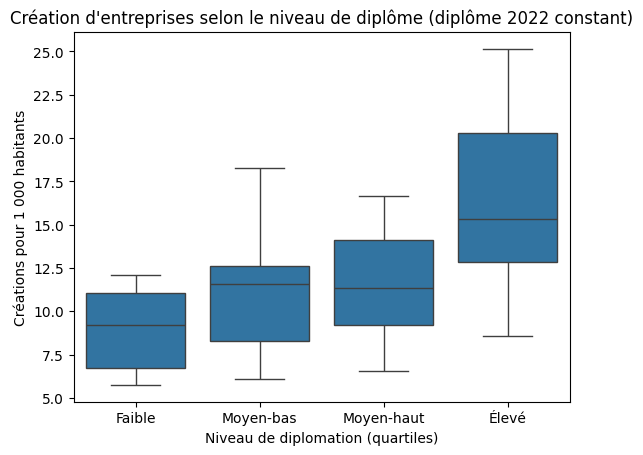

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

df["diplome_q"] = pd.qcut(
    df["Pourcentage_diplomes_superieur"],
    q=4,
    labels=["Faible", "Moyen-bas", "Moyen-haut", "Élevé"]
)

sns.boxplot(data=df, x="diplome_q", y="creations_per_1000")
plt.title("Création d'entreprises selon le niveau de diplôme (diplôme 2022 constant)")
plt.xlabel("Niveau de diplomation (quartiles)")
plt.ylabel("Créations pour 1 000 habitants")
plt.show()



#### Interprétation

Les boxplots montrent que les régions les plus diplômées présentent en médiane un taux de création d’entreprises plus élevé. Malgré un recouvrement entre groupes, on observe un gradient clair suggérant un lien positif entre capital humain et dynamisme entrepreneurial, sans préjuger d’un lien causal.

### Autres variables explicatives

L'effet des autres variables explicatives aurait également pu être étudié avec les méthodes présentés ci-dessus.
Pour éviter la répétition, nous commenterons leur effet dans la partie Modélisation

<h1 style="color: #C0392B;">
3. Modélisation </h1>

<h1 style="color: #C0392B;">
3.1. Régression linéaire 1 </h1>

Afin d'identifier les facteurs influençant le dynamisme entrepreneurial des régions, nous procédons à une régression linéaire multiple (Méthode des Moindres Carrés Ordinaires - OLS).Le modèle économétrique testé est le suivant :$$TauxCréation_i = \beta_0 + \beta_1 \cdot Diplôme + \beta_2 \cdot Chômage + \beta_3 \cdot VariationPop + \beta_4 \cdot Densité + \epsilon_i$$

Choix des variables :Variable expliquée ($Y$) : Le taux de création d'entreprises (pour 1000 habitants), indicateur direct du dynamisme entrepreneurial.

**Variables explicatives ($X$)** :
- **Capital Humain** : Le pourcentage de diplômés du supérieur (proxy du niveau de qualification de la région).
- **Conjoncture Économique** : Le taux de chômage (pour tester l'effet "push" vs "pull").
- **Dynamisme Démographique** : La variation de la population (attractivité du territoire)
- **Agglomération** : La densité de population (effets de métropolisation).

Hypothèse de modélisation : Nous utilisons une approche "Pooled OLS" sur l'ensemble de notre panel (130 observations : 13 régions $\times$ 10 années). Cette méthode permet d'inclure des variables structurelles invariantes sur la période étudiée (comme le niveau de diplôme, fixé ici à son niveau de 2022) et de mesurer leur impact global sur les disparités inter-régionales.

Pour créer le dataset contenant la variable explicative et les variables explicatives, nous l'avons fait dans le notebook "regression.ipynb" pour vérifier que les merges des datasets de nos variables explicatives s'effectuaient correctement'. Le dataset s'appelle 'regression1'.

Les données sur les diplômes des français n'étaient disponibles qu'en 2022 sur l'INSEE donc nous avons fait une **hypothèse de stabilité** :
Le niveau d'éducation d'une région change très lentement. On peut raisonnablement supposer que si une région est très diplômée en 2022, elle l'était aussi (relativement aux autres) en 2015.

In [17]:
from mes_fonctions import build_regression1_csv

# On crée la table de régression 

regression1 = build_regression1_csv(
    path_diplome="data/Variables explicatives/diplome_region.csv",
    path_chomage="data/Variables explicatives/chomage_format_long.csv",
    path_creation_per_1000="data/Variables explicatives/creation_per_1000.csv",
    path_population="data/Variables explicatives/population_par_region_annee.csv",
    out_csv_path="data/Variables explicatives/regression1.csv",
    drop_domtom=True,
)


In [18]:
y = regression1["creations_per_1000"]
X = sm.add_constant(regression1[
    [
        "Taux de chômage par région",
        "Pourcentage_diplomes_superieur",
        "variation_population_pourcentage",
        "densité de population",
    ]
])

results1 = sm.OLS(y, X).fit()
print(results1.summary())


                            OLS Regression Results                            
Dep. Variable:     creations_per_1000   R-squared:                       0.577
Model:                            OLS   Adj. R-squared:                  0.563
Method:                 Least Squares   F-statistic:                     42.58
Date:                Sun, 28 Dec 2025   Prob (F-statistic):           1.70e-22
Time:                        15:39:39   Log-Likelihood:                -316.14
No. Observations:                 130   AIC:                             642.3
Df Residuals:                     125   BIC:                             656.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

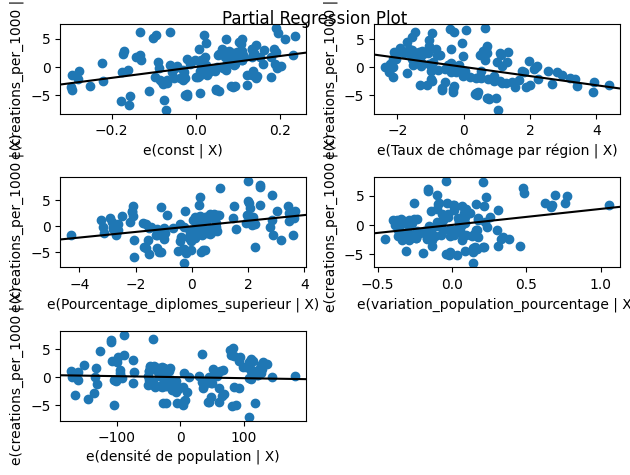

In [19]:
# Visualisation de l'effet des variables (non causal)

import statsmodels.api as sm
fig = sm.graphics.plot_partregress_grid(results1)


### 1. Performance globale du modèle.

**Qualité de l'ajustement ($R^2$)** : 
Le $R^2$ est de 0.577. Cela signifie que notre modèle explique 57,7 % de la variance du taux de création d'entreprises. 
Pour des données socio-économiques, c'est un score élevé, indiquant que les variables choisies sont très pertinentes pour expliquer le phénomène.Significativité globale (F-statistic) : La probabilité associée (Prob F-statistic: $1.70e-22$) est quasi nulle, ce qui confirme que le modèle dans son ensemble est statistiquement valide.

### 2. Analyse des déterminants (Variables significatives).
Trois variables ont un impact statistiquement significatif (P-value < 0.05) sur la création d'entreprise :
- **Le Taux de Chômage** (Coef: -0.82, P<0.001) :Impact : Il existe une relation négative forte. Toutes choses égales par ailleurs, une augmentation de 1 point du taux de chômage entraîne une baisse de 0.82 point du taux de création.Interprétation : Ce résultat valide l'effet "Pull" (opportunité). La création d'entreprise est favorisée par une bonne santé économique. L'hypothèse de l'entrepreneuriat de nécessité (effet "Push"), où le chômage pousserait à la création, est ici rejetée.
- **Le Capital Humain / Diplômes** (Coef: +0.53, P<0.001) :Impact : Relation positive. Une augmentation de 1 point du pourcentage de diplômés du supérieur augmente le taux de création de 0.53 point.Interprétation : Le niveau de qualification d'un territoire est un moteur essentiel de l'entrepreneuriat.
- **Le Dynamisme Démographique** (Coef: +2.72, P=0.003) :Impact : Relation positive très forte. Une région dont la population croît attire les créateurs. C'est un indicateur d'attractivité du territoire (demande locale croissante).

### 3. La variable non-significative.
La Densité de population (P=0.540) :Avec une P-value de 0.54 (bien supérieure au seuil de 0.05), nous ne pouvons pas conclure que la densité de population a un impact direct sur la création d'entreprises, une fois que l'on contrôle déjà pour le niveau d'éducation et le chômage. L'effet "métropole" passe probablement déjà par la variable des diplômés.

Note Méthodologique (Limites)Le test de Durbin-Watson est de 0.410, ce qui est faible (loin de la valeur cible de 2). Cela indique une présence d'autocorrélation positive dans les résidus. C'est attendu dans ce type de modèle "Pooled OLS" où les mêmes régions sont suivies sur plusieurs années. Bien que cela n'invalide pas les coefficients (la tendance reste vraie), cela suggère que la précision des intervalles de confiance pourrait être surestimée.

<h1 style="color: #C0392B;">
3.2 Régression linéaire 2 </h1>

On peut enlever la variable densité de population qui n'est pas statistiquement significative. A la place, on a décidé d'ajouter la variable sur le salaire moyen net. Les données INSEE étaient seulement disponibles de 2015 à 2023, ce qui réduit le nombre des points de la régression linéaire.

In [20]:
from mes_fonctions import build_regression2_csv

regression2 = build_regression2_csv(
    path_diplome="data/Variables explicatives/diplome_region.csv",
    path_chomage="data/Variables explicatives/chomage_format_long.csv",
    path_creation_per_1000="data/Variables explicatives/creation_per_1000.csv",
    path_population="data/Variables explicatives/population_par_region_annee.csv",
    path_salaires="data/Variables explicatives/salaires.csv",
    out_csv_path="data/Variables explicatives/regression2.csv",
    drop_domtom=True,
)


In [21]:
y = regression2["creations_per_1000"]
X = sm.add_constant(regression2[
    ["Taux de chômage par région", "Pourcentage_diplomes_superieur", "variation_population_pourcentage", "SALAIRE"]
])

results2 = sm.OLS(y, X).fit()

print(results2.summary())


                            OLS Regression Results                            
Dep. Variable:     creations_per_1000   R-squared:                       0.648
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     159.4
Date:                Sun, 28 Dec 2025   Prob (F-statistic):           3.49e-77
Time:                        15:39:40   Log-Likelihood:                -810.28
No. Observations:                 351   AIC:                             1631.
Df Residuals:                     346   BIC:                             1650.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

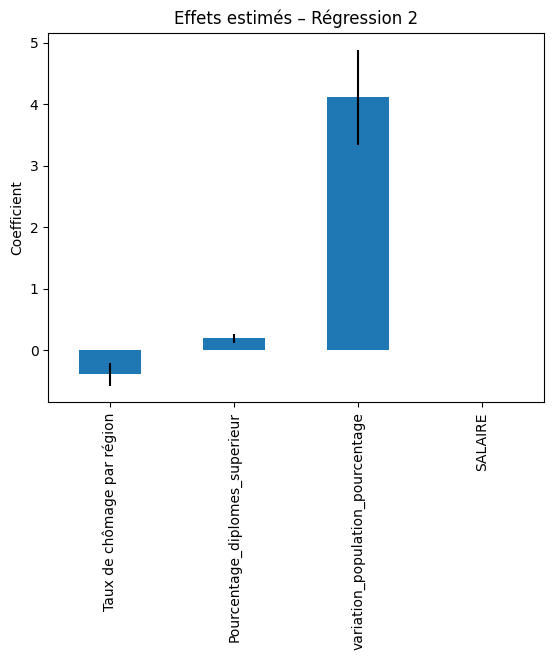

In [22]:
coef2 = results2.params.drop("const")
err2 = results2.bse.drop("const")

coef2.plot(kind="bar", yerr=1.96 * err2)
plt.title("Effets estimés – Régression 2")
plt.ylabel("Coefficient")
plt.show()




On a un R**2 haut (
=0.648) mais potentiellement **instable**

De plus, le coefficient lié à salaire est très faible, mais pour autant cette variable est significative ! Cela est lié à un effet d'échelle.

### A. Le problème de la Multicollinéarité (Condition Number)

Tout en bas, la note [2] : "The condition number is large".Ce que ça veut dire : nos variables explicatives se ressemblent trop.

Par exemple, une région avec des Salaires élevés est souvent aussi une région avec beaucoup de Diplômés.La conséquence : Le modèle a du mal à séparer l'impact du salaire de celui du diplôme. Cela peut inverser les signes (ce qui expliquerait pourquoi "Diplôme" est proche de 0 alors qu'on s'attendrait à un effet fortement positif). Le modèle "sait" prédire, mais il ne "comprend" pas vraiment qui fait quoi.

On va donc vérifier la corrélation entre nos variables explicatives avant de faire la régression. Cela confirmera si "Salaire" et "Diplôme" disent la même chose.

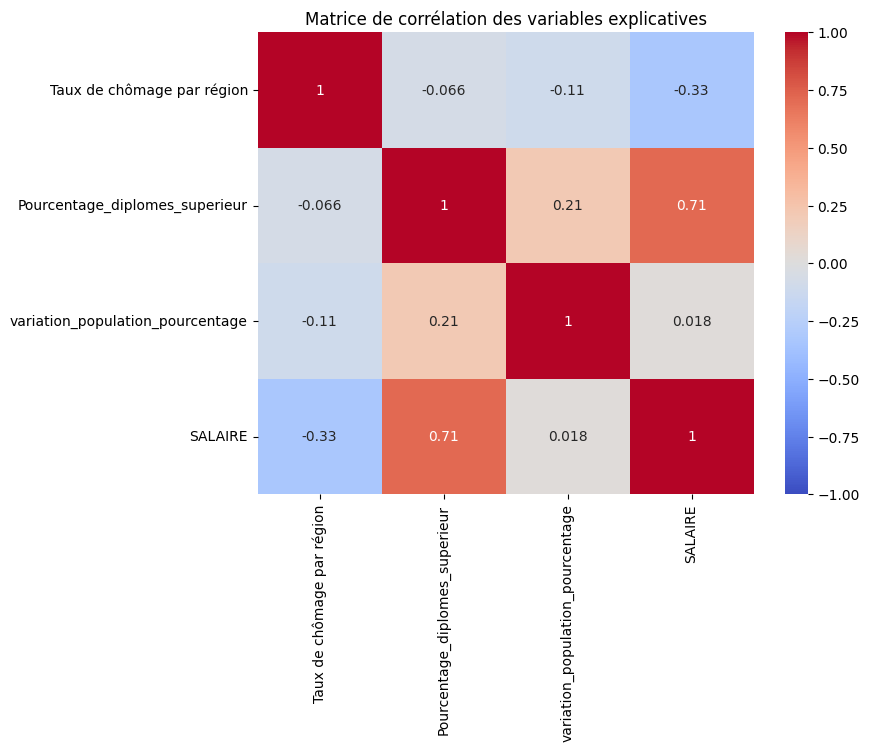

In [23]:
# On reprend nos features
features = [
    'Taux de chômage par région',
    'Pourcentage_diplomes_superieur',
    'variation_population_pourcentage',
    'SALAIRE'
]

# Calcul de la matrice
corr_matrix = regression2[features].corr()

# Affichage avec une Heatmap (carte de chaleur)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matrice de corrélation des variables explicatives")
plt.show()

La coefficient de corrélation entre Pourcentage_diplomes_superieur et SALAIRE vaut 0.71.

En statistiques, une corrélation de 0.71 est considérée comme très forte. Cela signifie que ces deux variables racontent quasiment la même histoire : les zones où les gens sont diplômés sont aussi les zones où les salaires sont élevés.

Pour le modèle (OLS classique), c'est un cauchemar. Il n'arrive pas à savoir si la création d'entreprise est due au diplôme ou à l'argent.

### B. LASSO pour déterminer les variables à conserver



La forte corrélation entre le salaire et le niveau de diplôme suggère une multicolinéarité potentielle. Un modèle LASSO est utilisé afin d’identifier la variable la plus informative, en pénalisant les variables redondantes.

In [24]:
# On standardise les variables

features = [
    'Taux de chômage par région', 
    'Pourcentage_diplomes_superieur',     
    'variation_population_pourcentage', 
    'SALAIRE'
]

X = regression2[features]
y = regression2['creations_per_1000']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [25]:
# Régression LASSO

lasso = LassoCV(cv=5, random_state=0)
lasso.fit(X_scaled, y)


,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [26]:
# Visualisation des coefficients

lasso_coef = pd.Series(lasso.coef_, index=features)
print(lasso_coef)


Taux de chômage par région         -0.515305
Pourcentage_diplomes_superieur      0.981826
variation_population_pourcentage    1.355814
SALAIRE                             1.718685
dtype: float64


Bien que la corrélation élevée entre le salaire moyen et le niveau de diplôme engendre une multicolinéarité importante, susceptible de fragiliser l’interprétation des coefficients de la régression linéaire classique, l’estimation par LASSO, orientée vers la performance prédictive, conserve l’ensemble des deux variables. Cela indique que, du point de vue prédictif, ni le salaire ni le diplôme ne peuvent être éliminés sans perte d’information.

Dans une perspective interprétative, cette multicolinéarité empêche toutefois d’attribuer un effet marginal précis à chacune de ces variables prises isolément. L’interprétation retenue est donc conjointe : salaire et diplôme capturent ensemble un niveau de développement socio-économique régional favorable à la création d’entreprises, sans prétendre identifier un mécanisme causal distinct pour chacun.

<h1 style="color: #C0392B;"> 3.3 Régression linéaire </h1>


Pourquoi avons-nous testé la variable « Chômage au carré » ? 

L'objectif était de vérifier si la relation entre le chômage et la création d'entreprises était non-linéaire (c'est-à-dire si elle formait une courbe plutôt qu'une ligne droite).

L'hypothèse économique (Effet de seuil) : Nous soupçonnions un effet ambivalent du chômage. D'un côté, un chômage très élevé peut signaler une économie locale sinistrée où le pouvoir d'achat est trop faible pour soutenir de nouvelles entreprises. De l'autre, un chômage modéré peut inciter à la création d'entreprise par nécessité (faute de trouver un emploi salarié). Ainsi l'effet marginale du chômage sur la création d'entreprises ne serait pas constant.

La traduction mathématique : En ajoutant le terme au carré, nous cherchions une forme en "U" ou en "U inversé" (cloche). Cela permet de détecter un point de bascule (un seuil de chômage) à partir duquel la tendance s'inverse.

In [28]:
from mes_fonctions import build_regression3_csv

regression3 = build_regression3_csv(
    path_diplome="data/Variables explicatives/diplome_region.csv",
    path_chomage="data/Variables explicatives/chomage_format_long.csv",
    path_creation_per_1000="data/Variables explicatives/creation_per_1000.csv",
    path_population="data/Variables explicatives/population_par_region_annee.csv",
    path_salaires="data/Variables explicatives/salaires.csv",
    out_csv_path="data/Variables explicatives/regression3.csv",
)


In [29]:
import statsmodels.api as sm

y = regression3["creations_per_1000"]

X = sm.add_constant(
    regression3[
        [
            "Taux de chômage par région",
            "chomage_carre",
            "Pourcentage_diplomes_superieur",
            "variation_population_pourcentage",
            "SALAIRE",
        ]
    ]
)

results3 = sm.OLS(y, X).fit()
print(results3.summary())


                            OLS Regression Results                            
Dep. Variable:     creations_per_1000   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.703
Method:                 Least Squares   F-statistic:                     154.2
Date:                Sun, 28 Dec 2025   Prob (F-statistic):           8.98e-83
Time:                        15:40:50   Log-Likelihood:                -699.73
No. Observations:                 324   AIC:                             1411.
Df Residuals:                     318   BIC:                             1434.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

Le modèle explique une part importante de la variance du taux de création d’entreprises (R² ≈ 0,71), indiquant un bon pouvoir explicatif global. La part de diplômés du supérieur, la variation de population et le salaire moyen ont tous un effet positif et statistiquement significatif, suggérant que le capital humain, l’attractivité démographique et le niveau de vie sont des déterminants majeurs du dynamisme entrepreneurial régional.

En revanche, ni le taux de chômage ni son terme quadratique ne sont significatifs, ce qui ne permet pas de mettre en évidence un effet non linéaire du chômage sur la création d’entreprises une fois les autres variables contrôlées.

<h1 style="color: #C0392B;"> 
Conclusion </h1>

<h1 style="color: #C0392B;"> 
Apports </h1>

Ce projet a été conduit selon une démarche méthodologique rigoureuse, depuis la construction minutieuse des données jusqu’à l’analyse économétrique. Une attention particulière a été portée à **la définition des variables**, à l’harmonisation de sources hétérogènes et au traitement des dimensions spatiales et temporelles, afin de garantir la cohérence et la comparabilité des observations.

Les analyses descriptives et économétriques ont été menées de manière progressive et justifiée, en testant plusieurs spécifications et en confrontant systématiquement les résultats aux hypothèses économiques sous-jacentes. Cette approche permet non seulement d’interpréter les résultats de façon prudente, mais aussi de vérifier leur robustesse.

Dans l’ensemble, ce travail mobilise l’ensemble des compétences attendues **— manipulation de données, visualisation, modélisation et interprétation —** et illustre une capacité à conduire une analyse de données complète, structurée et reproductible.

<h1 style="color: #C0392B;"> 
Bilan </h1>

L’analyse met en évidence de fortes disparités régionales dans la création d’entreprises, principalement associées à des caractéristiques structurelles des territoires telles que le capital humain, le dynamisme démographique, le niveau de vie et, plus largement, les conditions du marché du travail. Les régions bénéficiant d’un **environnement socio-économique** plus favorable présentent en moyenne un dynamisme entrepreneurial plus élevé.

Un résultat marquant est que ces relations demeurent relativement **stables** à travers les différentes spécifications du modèle, suggérant que les déterminants identifiés relèvent de facteurs profonds et persistants plutôt que de phénomènes conjoncturels. La création d’entreprises apparaît ainsi étroitement liée à l’attractivité globale des territoir